In [1]:
!pip install fairlearn pgmpy optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from fairlearn.adversarial import AdversarialFairnessClassifier
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import joblib
import os
from fairlearn.metrics import selection_rate
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True  
    torch.backends.cudnn.benchmark = False      

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

CACHE_DIR = '/kaggle/working/'
os.makedirs(CACHE_DIR, exist_ok=True)

BEST_PARAMS = {
    'german': {'lambda_adv': 0.15, 'alpha_bbn': 1.0, 'lr': 0.0015, 'hidden_dim': 128},
    'compas': {'lambda_adv': 0.5, 'alpha_bbn': 2.0, 'lr': 0.002, 'hidden_dim': 96},
    'bank': {'lambda_adv': 0.15, 'alpha_bbn': 1.0, 'lr': 0.0015, 'hidden_dim': 128},
    'hospital': {'lambda_adv': 0.1, 'alpha_bbn': 0.3, 'lr': 0.001, 'hidden_dim': 96},
    'lawschool': {'lambda_adv': 0.5, 'alpha_bbn': 5.0, 'lr': 0.0001, 'hidden_dim': 64},
    'adult': {'lambda_adv': 0.1, 'alpha_bbn': 0.5, 'lr': 0.001, 'hidden_dim': 128}
}

Using device: cuda


above hyperparams are the ones i got from tuning (except adult ofc). Here is the detail for the hyperparam tuning 

# ✅ **Fair-BBN Hyperparameter Tuning — Final Combined Summary (Short + Complete)**

The system performs a **dataset-aware smart grid search** to find hyperparameters that best balance **accuracy** and **fairness** for the Fair-BBN + AdapterNN model.

---

# **1. Hyperparameter Grid (Where It Came From)**

A **manually-designed**, dataset-specific grid (not random, not sklearn).
Ranges chosen based on fairness literature + model stability:

* **λ_adv** → adversarial fairness weight (0.1–3.0)
* **α_bbn** → BBN prior weight (0.3–5)
* **lr** → learning rate (1e-4 → 2e-3)
* **hidden_dim** → NN width (64–160 depending on dataset size)

Different datasets get different ranges (lawschool larger fairness weights, adult larger hidden_dim, etc.).

---

# **2. Method Used → Smart Grid Search (Not Plain Grid Search)**

A full Cartesian search but enhanced with intelligence:

### ✔ Full grid enumeration

### ✔ Manual grid + custom trainer

### ✔ Try/except (avoids crashes)

### ✔ Early stopping inside training (fairness-based)

### ✔ Dataset-specific metric weights

### ✔ Ranking by composite score

### ✔ Baseline accuracy comparison

### ✔ Full results stored + sorted

Formula for number of combos:

```
total_combinations = ∏ len(param_grid[param])
```

---

# **3. What Is Optimized? → Composite Score (Accuracy + Fairness)**

For each hyperparameter combination:

### **Accuracy score**

Relative to baseline:

```
acc_score = accuracy / baseline_accuracy
```

### **Fairness score**

Fairness metrics = |DP diff|, |EO diff|, |EO FP diff|, etc.
We take the worst violation:

```
max_fairness = max(|DP|, |EO|, ...)
fair_score = 1 - min(max_fairness, 1.0)
```

### **Final Composite Score**

Weights depend on dataset (e.g., fairness heavier for lawschool):

```
composite_score =
      weight_acc * acc_score
    + weight_fairness * fair_score
```

This is the **quantity being maximized**.

Why?

* Pure accuracy → biased model
* Pure fairness → destroys predictive power
* Composite score → optimal trade-off

---

# **4. Why the Search Is “Smart” (Not Normal Grid Search)**

### **1️⃣ Dataset-aware grids**

Each dataset gets its own λ_adv, α_bbn, lr, hidden_dim ranges.

### **2️⃣ Dynamic scoring weights**

Examples:

* Lawschool → fairness weight high (0.6)
* Adult → equal weights
* Compas/hospital → accuracy weighted more (0.6)

### **3️⃣ Fairness-based early stopping**

Training stops when:

```
current_fair_score > best_fair_score for patience iterations
```

### **4️⃣ Accuracy drop comparison**

Tracks:

```
accuracy_drop = baseline_accuracy - accuracy
```

### **5️⃣ Failure-safe execution**

Skips bad combinations automatically.

### **6️⃣ Comprehensive logging + DataFrame**

Every combination → metrics → sorted.

### **7️⃣ Multi-dataset orchestration**

`tune_all_datasets_fast()` runs tuning sequentially across:

GERMAN → COMPAS → BANK → HOSPITAL → LAWSCHOOL → ADULT

---

# **5. Full Evaluation Metrics Used**

From each training run:

* **Accuracy**
* **Δ Accuracy vs baseline**
* **DP diff**
* **EO diff**
* **EO FP diff**
* **EO FN diff**
* **Max fairness violation**
* **Avg fairness violation**

Only fairness metrics are absolute values.

In [3]:
def clean_numeric_column(series):
    series = pd.to_numeric(series, errors='coerce')
    series = series.replace([np.inf, -np.inf], np.nan)
    series = series.fillna(series.median())
    return series

def safe_qcut(series, q=5):
    series = clean_numeric_column(series)
    if series.nunique() <= 1:
        return pd.Series(0, index=series.index, dtype=int)
    try:
        return pd.qcut(series, q, labels=False, duplicates='drop').fillna(0).astype(int)
    except:
        try:
            return pd.cut(series, q, labels=False, duplicates='drop').fillna(0).astype(int)
        except:
            return pd.Series(0, index=series.index, dtype=int)

**clean_numeric_column** → *Convert anything to numeric, remove bad values, and fill missing with median.*


**safe_qcut** → *Create safe quantile-based bins from a column, falling back to simpler binning if needed.*

In [4]:
def preprocess_adult_for_fair_bbn(csv_path='/kaggle/input/all-datasets/adult.csv', use_cache=True):
    cache_file = os.path.join(CACHE_DIR, 'preproc_adult.pkl')
    if use_cache and os.path.exists(cache_file):
        print("Loading cached Adult data...")
        return joblib.load(cache_file)
    
    df = pd.read_csv(csv_path)
    df = df[~df.isin(['?']).any(axis=1)].reset_index(drop=True)
    df['income'] = np.where(df['income']=='>50K', 1, 0)
    
    race_map = {"White": 0,"Black": 1,"Asian-Pac-Islander": 2,"Amer-Indian-Eskimo": 3,"Other": 4}
    sex_map = {"Male": 0,"Female": 1}
    df['race_label'] = df['race'].map(race_map)
    df['sex_label'] = df['sex'].map(sex_map)
    
    categorical_cols = ['workclass','education','marital.status','occupation','relationship','native.country']
    numeric_cols = ['age','fnlwgt','education.num','capital.gain','capital.loss','hours.per.week']
    
    for col in numeric_cols:
        df[col] = clean_numeric_column(df[col])
    
    preproc = ColumnTransformer([
        ('num', Pipeline([('scaler', StandardScaler())]), numeric_cols),
        ('cat', Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
    ])
    
    bbn_df = df.copy()
    for col in numeric_cols:
        bbn_df[col] = safe_qcut(bbn_df[col], 5)
    for col in categorical_cols + ['race','sex']:
        bbn_df[col] = bbn_df[col].astype('category').cat.codes.astype(int)
    
    X = df.drop(columns=['income','race_label','sex_label'])
    y = df['income'].values
    sens_race = df['race_label']
    sens_sex = df['sex_label']
    
    X_train_raw, X_test_raw, y_train, y_test, sens_race_train, sens_race_test, sens_sex_train, sens_sex_test = \
        train_test_split(X, y, sens_race, sens_sex, test_size=0.2, stratify=y, random_state=seed)
    
    X_train_nn = preproc.fit_transform(X_train_raw)
    X_test_nn = preproc.transform(X_test_raw)
    
    bbn_train = bbn_df.loc[X_train_raw.index].reset_index(drop=True)
    bbn_test = bbn_df.loc[X_test_raw.index].reset_index(drop=True)
    
    result = {
        'X_train_nn': X_train_nn, 'X_test_nn': X_test_nn,
        'bbn_train_df': bbn_train, 'bbn_test_df': bbn_test,
        'y_train': y_train, 'y_test': y_test,
        'sens_race_train': sens_race_train.reset_index(drop=True),
        'sens_race_test': sens_race_test.reset_index(drop=True),
        'sens_sex_train': sens_sex_train.reset_index(drop=True),
        'sens_sex_test': sens_sex_test.reset_index(drop=True)
    }
    
    if use_cache:
        joblib.dump(result, cache_file)
        print(f"Cached Adult data to {cache_file}")
    
    return result

def preprocess_compas_for_fair_bbn(csv_path='/kaggle/input/all-datasets/compas-scores-two-years.csv', seed=42, use_cache=True):
    cache_file = os.path.join(CACHE_DIR, 'preproc_compas.pkl')
    if use_cache and os.path.exists(cache_file):
        print("Loading cached COMPAS data...")
        return joblib.load(cache_file)
    
    df = pd.read_csv(csv_path)
    df = df.loc[
        (df['days_b_screening_arrest'] <= 30) &
        (df['days_b_screening_arrest'] >= -30) &
        (df['is_recid'] != -1) &
        (df['c_charge_degree'] != 'O') &
        (df['score_text'] != 'N/A'),
        ['age','c_charge_degree','race','age_cat','score_text','sex',
         'priors_count','days_b_screening_arrest','decile_score',
         'juv_other_count','juv_misd_count','juv_fel_count',
         'c_charge_desc','is_recid','two_year_recid','c_jail_in','c_jail_out']
    ].reset_index(drop=True)
    
    race_map = {"African-American":0,"Caucasian":1,"Hispanic":2,"Other":3,"Asian":4,"Native American":5}
    sex_map = {"Male":0,"Female":1}
    df['race_label'] = df['race'].map(race_map)
    df['sex_label'] = df['sex'].map(sex_map)
    
    df['c_jail_in'] = pd.to_datetime(df['c_jail_in'])
    df['c_jail_out'] = pd.to_datetime(df['c_jail_out'])
    df['jail_time'] = (df['c_jail_out'] - df['c_jail_in']).dt.days
    df['jail_time'] = df['jail_time'].fillna(0)
    df = df.drop(columns=['c_jail_in','c_jail_out'])
    
    y = df['two_year_recid'].values
    sens_race = df['race_label']
    sens_sex = df['sex_label']
    
    numeric_cols = ['age','priors_count','days_b_screening_arrest','decile_score',
                    'jail_time','juv_other_count','juv_misd_count','juv_fel_count']
    categorical_cols = ['c_charge_degree','race','age_cat','score_text','sex','c_charge_desc']
    
    for col in numeric_cols:
        df[col] = clean_numeric_column(df[col])
    
    preproc = ColumnTransformer([
        ('num', Pipeline([('scaler', StandardScaler())]), numeric_cols),
        ('cat', Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
    ])
    
    bbn_df = df.copy()
    for col in numeric_cols:
        bbn_df[col] = safe_qcut(bbn_df[col], 5)
    for col in categorical_cols + ['race','sex']:
        bbn_df[col] = bbn_df[col].astype('category').cat.codes.astype(int)
    
    X = df.drop(columns=['is_recid','two_year_recid','race_label','sex_label'])
    X_train_raw, X_test_raw, y_train, y_test, sens_race_train, sens_race_test, sens_sex_train, sens_sex_test = \
        train_test_split(X, y, sens_race, sens_sex, test_size=0.2, stratify=y, random_state=seed)
    
    X_train_nn = preproc.fit_transform(X_train_raw)
    X_test_nn = preproc.transform(X_test_raw)
    
    bbn_train = bbn_df.loc[X_train_raw.index].reset_index(drop=True)
    bbn_test = bbn_df.loc[X_test_raw.index].reset_index(drop=True)
    
    result = {
        'X_train_nn': X_train_nn, 'X_test_nn': X_test_nn,
        'bbn_train_df': bbn_train, 'bbn_test_df': bbn_test,
        'y_train': y_train, 'y_test': y_test,
        'sens_race_train': sens_race_train.reset_index(drop=True),
        'sens_race_test': sens_race_test.reset_index(drop=True),
        'sens_sex_train': sens_sex_train.reset_index(drop=True),
        'sens_sex_test': sens_sex_test.reset_index(drop=True)
    }
    
    if use_cache:
        joblib.dump(result, cache_file)
        print(f"Cached COMPAS data to {cache_file}")
    
    return result

def preprocess_german_for_fair_bbn(csv_path="/kaggle/input/all-datasets/german.data", seed=42, use_cache=True):
    cache_file = os.path.join(CACHE_DIR, 'preproc_german.pkl')
    if use_cache and os.path.exists(cache_file):
        print("Loading cached German data...")
        return joblib.load(cache_file)
    
    column_names = [
        "status", "duration", "credit_history", "purpose", "amount", "savings", "employment",
        "installment_rate", "personal_status_sex", "other_debtors", "residence", "property", "age",
        "other_installment_plans", "housing", "number_credits", "job", "people_liable",
        "telephone", "foreign_worker", "credit"
    ]
    df = pd.read_csv(csv_path, sep=' ', names=column_names)
    
    sex_map = {'A91':'male','A92':'male','A93':'male','A94':'female','A95':'female'}
    df['sex'] = df['personal_status_sex'].map(sex_map)
    df['sex_label'] = df['sex'].map({'male':0,'female':1})
    df['age_label'] = (df['age'] >= 25).astype(int)
    df['foreign_worker_label'] = df['foreign_worker'].map({'A201':1,'A202':0})
    df['credit_label'] = df['credit'].map({1:1,2:0})
    df = df.drop(columns=['personal_status_sex','sex','age','foreign_worker','credit'])
    
    X = df.drop(columns=['credit_label'])
    y = df['credit_label'].values
    sensitive_sex = df['sex_label'].values
    sensitive_age = df['age_label'].values
    sensitive_foreign = df['foreign_worker_label'].values
    
    numerical_cols = ["duration", "amount", "installment_rate", "residence","number_credits","people_liable"]
    categorical_cols = [col for col in X.columns if col not in numerical_cols]
    
    for col in numerical_cols:
        df[col] = clean_numeric_column(df[col])
    
    preproc = ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])
    
    bbn_df = df.copy()
    for col in numerical_cols:
        bbn_df[col] = safe_qcut(bbn_df[col], 5)
    for col in categorical_cols + ['sex_label','age_label','foreign_worker_label']:
        bbn_df[col] = bbn_df[col].astype('category').cat.codes.astype(int)
    
    X_train_raw, X_test_raw, y_train, y_test, sens_age_train, sens_age_test, sens_sex_train, sens_sex_test, sens_foreign_train, sens_foreign_test = train_test_split(
        X, y, sensitive_age, sensitive_sex, sensitive_foreign,
        test_size=0.2, random_state=seed, stratify=y
    )
    
    pipeline = Pipeline([('preprocessor', preproc)])
    X_train_nn = pipeline.fit_transform(X_train_raw)
    X_test_nn = pipeline.transform(X_test_raw)
    
    bbn_train_df = bbn_df.loc[X_train_raw.index].reset_index(drop=True)
    bbn_test_df = bbn_df.loc[X_test_raw.index].reset_index(drop=True)
    
    result = {
        'X_train_nn': X_train_nn, 'X_test_nn': X_test_nn,
        'bbn_train_df': bbn_train_df, 'bbn_test_df': bbn_test_df,
        'y_train': y_train, 'y_test': y_test,
        'sens_age_train': sens_age_train, 'sens_age_test': sens_age_test,
        'sens_sex_train': sens_sex_train, 'sens_sex_test': sens_sex_test,
        'sens_foreign_train': sens_foreign_train, 'sens_foreign_test': sens_foreign_test
    }
    
    if use_cache:
        joblib.dump(result, cache_file)
        print(f"Cached German data to {cache_file}")
    
    return result

def preprocess_lawschool_for_fair_bbn(law_path="/kaggle/input/all-datasets/bar_pass_prediction.csv", use_cache=True):
    cache_file = os.path.join(CACHE_DIR, 'preproc_lawschool.pkl')
    if use_cache and os.path.exists(cache_file):
        print("Loading cached Law School data...")
        return joblib.load(cache_file)
    
    law_df = pd.read_csv(law_path)
    law_df.columns = [c.strip().lower() for c in law_df.columns]
    target_col, sens_race, sens_gender = 'pass_bar', 'race', 'sex'
    law_df = law_df.dropna(subset=[target_col, sens_race, sens_gender])
    
    for col in law_df.select_dtypes(include=[np.number]).columns:
        law_df[col] = clean_numeric_column(law_df[col])
    
    law_df['income'] = np.where(law_df['fam_inc'] > law_df['fam_inc'].median(), 1, 0)
    
    law_df[sens_race] = law_df[sens_race].astype('category')
    law_df[sens_gender] = law_df[sens_gender].astype('category')
    law_df['race_label'] = law_df[sens_race].cat.codes
    law_df['gender_label'] = law_df[sens_gender].cat.codes
    
    numeric_cols = [c for c in ['lsat','ugpa','zfygpa','zgpa','age','gpa','fam_inc'] if c in law_df.columns]
    categorical_cols = [c for c in ['tier','cluster','fulltime','parttime'] if c in law_df.columns]
    
    low_var_cols = [col for col in numeric_cols if law_df[col].nunique() <= 1]
    if low_var_cols:
        law_df = law_df.drop(columns=low_var_cols)
        numeric_cols = [c for c in numeric_cols if c not in low_var_cols]
    
    preproc = ColumnTransformer([
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])
    
    bbn_df = law_df.copy()
    for col in numeric_cols:
        bbn_df[col] = safe_qcut(law_df[col], 5)
    for col in categorical_cols + [sens_race, sens_gender]:
        bbn_df[col] = bbn_df[col].astype('category').cat.codes.astype(int)
    
    X = law_df[numeric_cols + categorical_cols + [sens_race, sens_gender]]
    y = law_df['income'].values
    sens_race_labels = law_df['race_label']
    sens_gender_labels = law_df['gender_label']
    
    X_train_raw, X_test_raw, y_train, y_test, sens_race_train, sens_race_test, sens_gender_train, sens_gender_test = \
        train_test_split(X, y, sens_race_labels, sens_gender_labels, test_size=0.2, stratify=y, random_state=seed)
    
    X_train_nn = preproc.fit_transform(X_train_raw)
    X_test_nn = preproc.transform(X_test_raw)
    
    bbn_train = bbn_df.loc[X_train_raw.index].reset_index(drop=True)
    bbn_test = bbn_df.loc[X_test_raw.index].reset_index(drop=True)
    
    result = {
        'X_train_nn': X_train_nn, 'X_test_nn': X_test_nn,
        'bbn_train_df': bbn_train, 'bbn_test_df': bbn_test,
        'y_train': y_train, 'y_test': y_test,
        'sens_race_train': sens_race_train.reset_index(drop=True),
        'sens_race_test': sens_race_test.reset_index(drop=True),
        'sens_gender_train': sens_gender_train.reset_index(drop=True),
        'sens_gender_test': sens_gender_test.reset_index(drop=True)
    }
    
    if use_cache:
        joblib.dump(result, cache_file)
        print(f"Cached Law School data to {cache_file}")
    
    return result

def preprocess_diabetes_hospital_for_fair_bbn(csv_path='/kaggle/input/all-datasets/diabetes_hospital_fairlearn.csv', seed=42, use_cache=True):
    cache_file = os.path.join(CACHE_DIR, 'preproc_hospital.pkl')
    if use_cache and os.path.exists(cache_file):
        print("Loading cached Hospital data...")
        return joblib.load(cache_file)
    
    df = pd.read_csv(csv_path)
    drop_cols = ["max_glu_serum", "A1Cresult", "readmitted.1"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    df = df[~df.isin(['Missing']).any(axis=1)]
    df = df.dropna(subset=['race', 'gender']).reset_index(drop=True)
    
    age_map = {
        "'0-10'": 5, "'10-20'": 15, "'20-30'": 25, "'30-40'": 35, "'40-50'": 45,
        "'50-60'": 55, "'60-70'": 65, "'70-80'": 75, "'80-90'": 85, "'90-100'": 95,
        "'30 years or younger'": 20,
        "'30-60 years'": 45,
        "'Over 60 years'": 70
    }
    df['age'] = df['age'].replace(age_map).astype(float)
    df['readmit_binary'] = df['readmit_binary'].astype(int)
    df['race'] = df['race'].astype(str).str.strip()
    df['gender'] = df['gender'].astype(str).str.strip()
    
    race_map = {v: i for i, v in enumerate(df['race'].unique())}
    gender_map = {'Male': 0, 'Female': 1}
    df['race_label'] = df['race'].map(race_map)
    df['gender_label'] = df['gender'].map(gender_map)
    df['race_label'] = df['race_label'].fillna(0).astype(int)
    df['gender_label'] = df['gender_label'].fillna(0).astype(int)
    
    categorical_cols = [
        'discharge_disposition_id', 'admission_source_id',
        'medical_specialty', 'primary_diagnosis',
        'insulin', 'change', 'diabetesMed'
    ]
    numeric_cols = [
        'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
        'num_medications', 'number_diagnoses', 'had_emergency',
        'had_inpatient_days', 'had_outpatient_days', 'medicare', 'medicaid'
    ]
    
    for col in numeric_cols:
        df[col] = clean_numeric_column(df[col])
    
    preproc = ColumnTransformer([
        ('num', Pipeline([('scaler', StandardScaler())]), numeric_cols),
        ('cat', Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
    ])
    
    bbn_df = df.copy()
    for col in numeric_cols:
        bbn_df[col] = safe_qcut(bbn_df[col], 5)
    for col in categorical_cols + ['race', 'gender']:
        bbn_df[col] = bbn_df[col].astype('category').cat.codes.astype(int)
    
    X = df.drop(columns=['readmit_binary', 'race_label', 'gender_label'])
    y = df['readmit_binary'].values
    sens_race = df['race_label']
    sens_gender = df['gender_label']
    
    X_train_raw, X_test_raw, y_train, y_test, sens_race_train, sens_race_test, sens_gender_train, sens_gender_test = \
        train_test_split(X, y, sens_race, sens_gender, test_size=0.2, stratify=y, random_state=seed)
    
    X_train_nn = preproc.fit_transform(X_train_raw)
    X_test_nn = preproc.transform(X_test_raw)
    
    bbn_train = bbn_df.loc[X_train_raw.index].reset_index(drop=True)
    bbn_test = bbn_df.loc[X_test_raw.index].reset_index(drop=True)
    
    result = {
        'X_train_nn': X_train_nn,
        'X_test_nn': X_test_nn,
        'bbn_train_df': bbn_train,
        'bbn_test_df': bbn_test,
        'y_train': y_train,
        'y_test': y_test,
        'sens_race_train': sens_race_train.reset_index(drop=True),
        'sens_race_test': sens_race_test.reset_index(drop=True),
        'sens_sex_train': sens_gender_train.reset_index(drop=True),
        'sens_sex_test': sens_gender_test.reset_index(drop=True)
    }
    
    if use_cache:
        joblib.dump(result, cache_file)
        print(f"Cached Hospital data to {cache_file}")
    
    return result

def preprocess_bank_for_fair_bbn(csv_path='/kaggle/input/all-datasets/bank-full.csv', seed=42, use_cache=True):
    cache_file = os.path.join(CACHE_DIR, 'preproc_bank.pkl')
    if use_cache and os.path.exists(cache_file):
        print("Loading cached Bank data...")
        return joblib.load(cache_file)
    
    try:
        df = pd.read_csv(csv_path, sep=';')
    except:
        df = pd.read_csv(csv_path, sep=',')
    df = df.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)
    target_col = 'y' if 'y' in df.columns else 'deposit' if 'deposit' in df.columns else 'subscribed'
    if target_col not in df.columns:
        target_col = df.columns[-1]
    df = df[~df.isin(['unknown']).any(axis=1)].reset_index(drop=True)
    df['y'] = np.where(df[target_col].isin(['yes', 'y', 'true', '1']), 1, 0)
    
    from sklearn.preprocessing import LabelEncoder
    le_marital = LabelEncoder()
    df['marital_label'] = le_marital.fit_transform(df['marital'])
    le_job = LabelEncoder()
    df['job_label'] = le_job.fit_transform(df['job'])
    
    categorical_cols = [col for col in ['job', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'] if col in df.columns]
    numeric_cols = [col for col in ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'] if col in df.columns]
    
    for col in numeric_cols:
        df[col] = clean_numeric_column(df[col])
    
    for col in ['balance', 'duration', 'pdays', 'previous']:
        if col in df.columns:
            df[col] = df[col].clip(upper=df[col].quantile(0.99))
    
    preproc = ColumnTransformer([
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])
    
    bbn_df = df.copy()
    for col in numeric_cols:
        bbn_df[col] = safe_qcut(bbn_df[col], 5)
    for col in categorical_cols + ['marital', 'job']:
        bbn_df[col] = bbn_df[col].astype('category').cat.codes.astype(int)
    
    X = df.drop(columns=['y', 'marital_label', 'job_label'])
    y = df['y'].values
    sens_marital = df['marital_label']
    sens_job = df['job_label']
    
    X_train_raw, X_test_raw, y_train, y_test, sens_marital_train, sens_marital_test, sens_job_train, sens_job_test = \
        train_test_split(X, y, sens_marital, sens_job, test_size=0.2, stratify=y, random_state=seed)
    
    X_train_nn = preproc.fit_transform(X_train_raw)
    X_test_nn = preproc.transform(X_test_raw)
    
    bbn_train = bbn_df.loc[X_train_raw.index].reset_index(drop=True)
    bbn_test = bbn_df.loc[X_test_raw.index].reset_index(drop=True)
    
    result = {
        'X_train_nn': X_train_nn, 'X_test_nn': X_test_nn,
        'bbn_train_df': bbn_train, 'bbn_test_df': bbn_test,
        'y_train': y_train, 'y_test': y_test,
        'sens_marital_train': sens_marital_train.reset_index(drop=True),
        'sens_marital_test': sens_marital_test.reset_index(drop=True),
        'sens_job_train': sens_job_train.reset_index(drop=True),
        'sens_job_test': sens_job_test.reset_index(drop=True)
    }
    
    if use_cache:
        joblib.dump(result, cache_file)
        print(f"Cached Bank data to {cache_file}")
    
    return result

1. **Load dataset & optional cache check**

   * Common: check `CACHE_DIR` for cached file; if present and `use_cache=True` return cached result; else `pd.read_csv(...)`.

2. **Initial row filtering / remove obvious missing tokens**

   * Adult: drop rows containing `'?'`.
   * COMPAS: apply COMPAS-specific filters (days_b_screening_arrest bounds, `is_recid != -1`, `c_charge_degree != 'O'`, `score_text != 'N/A'`).
   * German: nothing extra here beyond proper parsing (names assigned at read).
   * Law School: `dropna` rows missing target or sensitive columns.
   * Hospital: drop rows containing `"Missing"` and drop rows missing `race` or `gender`.
   * Bank: remove rows containing `"unknown"`.

3. **Normalize/clean column names or string columns**

   * Adult / COMPAS / German / Hospital / Law School: minimal/no global lowercase step (Law School explicitly lowercases column names).
   * Bank: convert all object/string columns to lowercase.

4. **Create / set target variable**

   * Adult: `income = 1 if >50K else 0`.
   * COMPAS: `y = two_year_recid` (and ensure `is_recid`/filters applied).
   * German: `credit_label = map({1:1,2:0})`.
   * Law School: `income = 1 if fam_inc > median else 0` (or `pass_bar` used depending on function).
   * Hospital: `readmit_binary` → ensure int.
   * Bank: determine target column (`y` or `deposit` or `subscribed`) then normalize to `y` binary.

5. **Create / map sensitive attributes to integer labels**

   * Adult: `race_label` (map) and `sex_label` (map).
   * COMPAS: `race_label` and `sex_label`.
   * German: derive `sex` from `personal_status_sex` → `sex_label`; create `age_label = (age >= 25)`; `foreign_worker_label`.
   * Law School: `race` and `sex` → categorical → `.cat.codes`.
   * Hospital: `race_label` (map unique values → ints), `gender_label` (Male/Female → 0/1).
   * Bank: `marital_label` and `job_label` via `LabelEncoder`.

6. **Feature derivation / special conversions (dataset-specific)**

   * COMPAS: parse `c_jail_in`/`c_jail_out` → `jail_time = (out - in).days`.
   * Hospital: convert age buckets (e.g. `"'20-30'"`) to numeric midpoints via `age_map`.
   * German: column names assigned and sex extracted from composite column.
   * Law School: drop low-variance numeric columns (nunique ≤ 1).
   * Bank: none beyond label encoding.

7. **Select numeric_cols and categorical_cols**

   * Common: decide lists per dataset (each function defines its own `numeric_cols` and `categorical_cols`).
   * Note: Law School & German dynamically build lists based on existing columns.

8. **Clean numeric columns (common routine)**

   * Common (all datasets): for each numeric column call `clean_numeric_column()` which:

     * converts to numeric (`pd.to_numeric(..., errors='coerce')`), replaces ±inf with NaN, fills NaN with median.

9. **Optional numeric clipping / outlier handling**

   * Bank: clip `['balance','duration','pdays','previous']` at the 99th percentile.
   * Others: no explicit clipping in your functions.

10. **Build preprocessing pipeline (NN features)**

    * Common: `ColumnTransformer` or `Pipeline` combining:

      * numeric pipeline: `StandardScaler()` for numeric_cols
      * categorical pipeline: `OneHotEncoder(handle_unknown='ignore')` for categorical_cols

11. **Create BBN (discretized) dataframe**

    * Common: make a copy `bbn_df = df.copy()`; then:

      * For each numeric column: `bbn_df[col] = safe_qcut(bbn_df[col], 5)` (quantile discretization with safe fallbacks).
      * For each categorical (and sensitive) column: `bbn_df[col] = bbn_df[col].astype('category').cat.codes.astype(int)`.

12. **Prepare X, y, and sensitive arrays**

    * Common: drop target & raw sensitive label columns from `X`, set `y` as numpy array, keep `sens_*` as separate arrays/Series.

13. **Train-test split**

    * Common: `train_test_split(X, y, sens_..., test_size=0.2, stratify=y, random_state=seed)`
    * Note: German and some others pass multiple sensitive arrays to split (so split preserves their alignment).

14. **Fit / transform NN-ready features**

    * Common: `X_train_nn = preproc.fit_transform(X_train_raw)` and `X_test_nn = preproc.transform(X_test_raw)` (or via a `Pipeline` wrapping the `ColumnTransformer`).

15. **Create BBN train/test subsets aligned with NN split**

    * Common: `bbn_train = bbn_df.loc[X_train_raw.index].reset_index(drop=True)` and similarly for test.

16. **Package results into `result` dict**

    * Common: include `'X_train_nn', 'X_test_nn', 'bbn_train_df', 'bbn_test_df', 'y_train','y_test'` and the sens_* train/test Series/arrays (reset indices where appropriate).

17. **Cache result and return**

    * Common: if `use_cache` then `joblib.dump(result, cache_file)` and print confirmation; finally `return result`.


In [5]:
class SimpleFairBBN:
    def __init__(self, feature_names=None, target_name='y'):
        self.feature_names = feature_names or []
        self.target_name = target_name
        self.model = None
        self.inference = None
        
    def fit(self, df_discrete, y, include_sensitive=True):
        data = df_discrete.copy().reset_index(drop=True)
        data[self.target_name] = y
        selected = list(df_discrete.columns[:8])
        #this 8 features is a random number lol
        if include_sensitive:
            sens_list = [
                'marital', 'job', 'race', 'sex', 'gender',
                'age_label', 'sex_label', 'foreign_worker_label'
            ]
            for s in sens_list:
                if s in df_discrete.columns and s not in selected:
                    selected.append(s)
        selected = [
            f for f in selected
            if pd.api.types.is_integer_dtype(df_discrete[f]) or 
               pd.api.types.is_categorical_dtype(df_discrete[f])
        ]
        self.feature_names = selected
        edges = [(f, self.target_name) for f in selected]
        self.model = DiscreteBayesianNetwork(edges)
        self.model.fit(
            data,
            estimator=BayesianEstimator,
            prior_type='BDeu',
            equivalent_sample_size=10
        )
        self.inference = VariableElimination(self.model)

    def predict_proba(self, df_discrete):
        Xdf = df_discrete.reset_index(drop=True)
        probs = []
        Y = self.target_name
        inference = self.inference
        for _, row in Xdf.iterrows():
            evidence = {
                f: int(row[f])
                for f in self.feature_names
                if f in row and not pd.isna(row[f])
            }
            if len(evidence) > 4:
                #even this evidence being 4 is a random number 
                evidence = dict(list(evidence.items())[:4])
            try:
                q = inference.query(variables=[Y], evidence=evidence or None)
                p1 = q.values[1] if len(q.values) == 2 else 0.5
            except Exception:
                p1 = 0.5
            probs.append(p1)
        return np.array(probs)

During model building, the method first copies the discrete dataframe and attaches the target variable. It then selects the first eight columns as the base features and optionally adds sensitive attributes like race, sex, or age labels. Because Bayesian Belief Networks require discrete inputs, the method keeps only integer or categorical columns. Edges are constructed from every feature directly to the target variable, and the network is trained using BDeu smoothing (BDeu smoothing is a Bayesian scoring method that adds a uniform prior to avoid zero-probability issues in discrete networks ). An inference engine based on variable elimination (variable elimination is an inference algorithm that computes probabilities by systematically summing out irrelevant variables from the network) is then created. For prediction, the model processes rows one by one—since BBNs cannot batch inference—by forming an evidence dictionary from the available discrete features, limiting evidence to at most four variables for speed and stability. The BBN is queried to obtain (P(y = 1 \mid \text{evidence})), and if inference fails or information is missing, it defaults to 0.5. The final output is the array of predicted probabilities.

In [6]:
class AdapterNN(nn.Module):
    def __init__(self, in_dim=3, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.out = nn.Linear(hidden_dim // 2, 1)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x, return_features=False):
        h = self.dropout(self.act(self.fc1(x)))
        h2 = self.dropout(self.act(self.fc2(h)))
        logit = self.out(h2)
        return (logit, h2) if return_features else logit

class AdversaryNN_Bank(nn.Module):
    def __init__(self, in_dim, marital_classes, job_classes):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(in_dim, 32), nn.ReLU(), nn.Dropout(0.2))
        self.marital_head = nn.Linear(32, marital_classes)
        self.job_head = nn.Linear(32, job_classes)

    def forward(self, x):
        s = self.shared(x)
        return self.marital_head(s), self.job_head(s)

class AdversaryNN_LawSchool(nn.Module):
    def __init__(self, in_dim, race_classes, gender_classes):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(in_dim, 32), nn.ReLU(), nn.Dropout(0.2))
        self.race_head = nn.Linear(32, race_classes)
        self.gender_head = nn.Linear(32, gender_classes)

    def forward(self, x):
        s = self.shared(x)
        return self.race_head(s), self.gender_head(s)

class AdversaryNN_Adult(nn.Module):
    def __init__(self, in_dim, race_classes, sex_classes):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(in_dim, 32), nn.ReLU(), nn.Dropout(0.2))
        self.race_head = nn.Linear(32, race_classes)
        self.sex_head = nn.Linear(32, sex_classes)

    def forward(self, x):
        s = self.shared(x)
        return self.race_head(s), self.sex_head(s)

class AdversaryNN_COMPAS(nn.Module):
    def __init__(self, in_dim, race_classes, sex_classes):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(in_dim, 32), nn.ReLU(), nn.Dropout(0.2))
        self.race_head = nn.Linear(32, race_classes)
        self.sex_head = nn.Linear(32, sex_classes)

    def forward(self, x):
        s = self.shared(x)
        return self.race_head(s), self.sex_head(s)

class AdversaryNN_German(nn.Module):
    def __init__(self, in_dim, age_classes, sex_classes, foreign_classes):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(in_dim, 32), nn.ReLU(), nn.Dropout(0.2))
        self.age_head = nn.Linear(32, age_classes)
        self.sex_head = nn.Linear(32, sex_classes)
        self.foreign_head = nn.Linear(32, foreign_classes)

    def forward(self, x):
        s = self.shared(x)
        return self.age_head(s), self.sex_head(s), self.foreign_head(s)

class AdversaryNN_Hospital(nn.Module):
    def __init__(self, in_dim, race_classes, sex_classes):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(in_dim, 32), nn.ReLU(), nn.Dropout(0.2))
        self.race_head = nn.Linear(32, race_classes)
        self.sex_head = nn.Linear(32, sex_classes)

    def forward(self, x):
        s = self.shared(x)
        return self.race_head(s), self.sex_head(s)

AdapterNN is a small MLP that turns raw inputs into a compact hidden vector and a single prediction logit.
It has two layers with ReLU + dropout: the first expands features, the second compresses them.
The final layer outputs the main task logit, and when return_features=True, it also returns the compressed hidden representation (h2) for adversarial training.
Each AdversaryNN_* takes the Adapter’s hidden features and tries to predict sensitive attributes (like race, sex, age, marital status, job).
All adversaries follow the same structure:
a shared layer learns general patterns from the features, and multiple heads (one per sensitive attribute) output class logits for each sensitive variable.
Different datasets have different sensitive attributes, so each class has different heads:

Bank → marital, job

LawSchool → race, gender

Adult → race, sex

COMPAS → race, sex

German → age, sex, foreign_worker

Hospital → race, sex

Their purpose: pressure the main model to unlearn sensitive information by trying to extract it.

The Adapter learns useful features to help the main model make predictions.
The Adversary tries to read those features and guess sensitive attributes (like race, sex, age).
During training, the Adapter is penalized whenever the Adversary succeeds.
So the Adapter learns to hide sensitive information inside its features, while still keeping the information needed for the main task.
This tug-of-war makes the final model fairer, because sensitive traits become harder to recover.

In [7]:
def train_fair_bbn_adapter(data_dict, dataset_type, lambda_adv=0.5, alpha_bbn=0.5, epochs=60, batch_size=256, lr=1e-3, hidden_dim=64, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    X_train_nn, X_test_nn = data_dict['X_train_nn'], data_dict['X_test_nn']
    bbn_train_df, bbn_test_df = data_dict['bbn_train_df'], data_dict['bbn_test_df']
    y_train, y_test = data_dict['y_train'], data_dict['y_test']

    config = {
        'german': {
            'sens_attrs': [('sens_age_train', 'sens_age_test'), ('sens_sex_train', 'sens_sex_test'), ('sens_foreign_train', 'sens_foreign_test')],
            'marginal_features': [['age_label'], ['sex_label'], ['foreign_worker_label']],
            'adversary': AdversaryNN_German,
            'adv_kwargs': {'age_classes': 2, 'sex_classes': 2, 'foreign_classes': 2},
            'target_name': 'credit_label'
        },
        'compas': {
            'sens_attrs': [('sens_race_train', 'sens_race_test'), ('sens_sex_train', 'sens_sex_test')],
            'marginal_features': [['race'], ['sex']],
            'adversary': AdversaryNN_COMPAS,
            'adv_kwargs': {},
            'target_name': 'two_year_recid'
        },
        'adult': {
            'sens_attrs': [('sens_race_train', 'sens_race_test'), ('sens_sex_train', 'sens_sex_test')],
            'marginal_features': [['race'], ['sex']],
            'adversary': AdversaryNN_Adult,
            'adv_kwargs': {},
            'target_name': 'income'
        },
        'bank': {
            'sens_attrs': [('sens_marital_train', 'sens_marital_test'), ('sens_job_train', 'sens_job_test')],
            'marginal_features': [['marital'], ['job']],
            'adversary': AdversaryNN_Bank,
            'adv_kwargs': {},
            'features_subset': ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'marital', 'job'],
            'target_name': 'y'
        },
        'lawschool': {
            'sens_attrs': [('sens_race_train', 'sens_race_test'), ('sens_gender_train', 'sens_gender_test')],
            'marginal_features': [['race'], ['gender']],
            'adversary': AdversaryNN_LawSchool,
            'adv_kwargs': {},
            'features_subset': ['lsat', 'ugpa', 'fulltime', 'fam_inc', 'age', 'race', 'gender'],
            'target_name': 'income'
        },
        'hospital': {
            'sens_attrs': [('sens_race_train', 'sens_race_test'), ('sens_sex_train', 'sens_sex_test')],
            'marginal_features': [['race'], ['gender']],
            'adversary': AdversaryNN_Hospital,
            'adv_kwargs': {},
            'target_name': 'readmit_binary'
        },
    }

    cfg = config[dataset_type]

    if dataset_type == 'lawschool':
        lambda_adv *= 2
        alpha_bbn *= 2
        epochs = 120
        patience = 25
    else:
        patience = 15

    if 'features_subset' in cfg:
        cols = [f for f in cfg['features_subset'] if f in bbn_train_df.columns]
        bbn_train_sub = bbn_train_df[cols]
        bbn_test_sub = bbn_test_df[cols]
    else:
        bbn_train_sub = bbn_train_df
        bbn_test_sub = bbn_test_df

    baseline = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=seed, early_stopping=True, learning_rate_init=0.001)
    baseline.fit(X_train_nn, y_train)
    base_pred = baseline.predict(X_test_nn)
    base_acc = accuracy_score(y_test, base_pred)

    base_results = {'pred': base_pred, 'acc': base_acc}

    for train_attr, test_attr in cfg['sens_attrs']:
        sens_test = data_dict[test_attr]
        name = train_attr.replace('sens_', '').replace('_train', '')
        base_results[f'{name}_dp'] = demographic_parity_difference(y_test, base_pred, sensitive_features=sens_test)
        base_results[f'{name}_eo'] = equalized_odds_difference(y_test, base_pred, sensitive_features=sens_test)

    bbn = SimpleFairBBN(feature_names=list(bbn_train_sub.columns), target_name=cfg['target_name'])
    bbn.fit(bbn_train_sub, y_train, include_sensitive=True)

    p_train = bbn.predict_proba(bbn_train_sub).reshape(-1, 1)
    p_test = bbn.predict_proba(bbn_test_sub).reshape(-1, 1)

    marg_train = [p_train]
    marg_test = [p_test]

    for feat in cfg['marginal_features']:
        marg_train.append(bbn.predict_proba(bbn_train_sub[feat]).reshape(-1, 1))
        marg_test.append(bbn.predict_proba(bbn_test_sub[feat]).reshape(-1, 1))

    adapter_in_train = torch.tensor(np.hstack(marg_train), dtype=torch.float32).to(device)
    adapter_in_test = torch.tensor(np.hstack(marg_test), dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32).to(device)
    y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32).to(device)

    sens_tensors = []
    for train_attr, _ in cfg['sens_attrs']:
        s = data_dict[train_attr]
        s = s.values if hasattr(s, 'values') else s
        sens_tensors.append(torch.tensor(s.astype(int), dtype=torch.long).to(device))

    train_dataset = TensorDataset(adapter_in_train, y_train_t, *sens_tensors)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              generator=torch.Generator().manual_seed(seed))

    adapter = AdapterNN(in_dim=len(marg_train), hidden_dim=hidden_dim).to(device)

    adv_kwargs = cfg['adv_kwargs'].copy()
    adv_kwargs['in_dim'] = hidden_dim // 2

    for train_attr, _ in cfg['sens_attrs']:
        name = train_attr.replace('sens_', '').replace('_train', '')
        key = f'{name}_classes'
        if key not in adv_kwargs:
            adv_kwargs[key] = len(np.unique(data_dict[train_attr]))

    adversary = cfg['adversary'](**adv_kwargs).to(device)

    adapter_opt = optim.Adam(adapter.parameters(), lr=lr, weight_decay=1e-5)
    adv_opt = optim.Adam(adversary.parameters(), lr=lr * 1.5, weight_decay=1e-5)

    bce = nn.BCEWithLogitsLoss()
    ce = nn.CrossEntropyLoss()

    best_fair = float('inf')
    no_imp = 0
    best_state = None

    for epoch in range(epochs):
        adapter.train()
        adversary.train()
        tot_a = 0
        tot_adv = 0

        for batch in train_loader:
            x, yb = batch[0], batch[1]
            sens = batch[2:]

            with torch.no_grad():
                _, f = adapter(x, return_features=True)

            adv_opt.zero_grad()

            out = adversary(f)
            if isinstance(out, tuple):
                adv_loss = sum(ce(out[i], sens[i]) for i in range(len(out))) / len(out)
            else:
                adv_loss = sum(ce(out[i], sens[i]) for i in range(len(sens))) / len(sens)

            adv_loss.backward()
            torch.nn.utils.clip_grad_norm_(adversary.parameters(), 1.0)
            adv_opt.step()
            tot_adv += adv_loss.item()

            adapter_opt.zero_grad()
            logit, f = adapter(x, return_features=True)
            pred_loss = bce(logit, yb)

            out2 = adversary(f)
            if isinstance(out2, tuple):
                adv_la = sum(ce(out2[i], sens[i]) for i in range(len(out2))) / len(out2)
            else:
                adv_la = sum(ce(out2[i], sens[i]) for i in range(len(sens))) / len(sens)

            dp = []
            for s in sens:
                u = torch.unique(s)
                if len(u) > 1:
                    m = [f[s == ui].mean(dim=0) for ui in u if (s == ui).sum() > 0]
                    for i in range(len(m)):
                        for j in range(i + 1, len(m)):
                            dp.append(torch.abs(m[i] - m[j]).mean())
            dp_pen = torch.mean(torch.stack(dp)) if dp else torch.tensor(0.0).to(device)

            loss = pred_loss - lambda_adv * adv_la + alpha_bbn * dp_pen
            loss.backward()
            torch.nn.utils.clip_grad_norm_(adapter.parameters(), 1.0)
            adapter_opt.step()
            tot_a += loss.item()

        if epoch % 10 == 0:
            adapter.eval()
            with torch.no_grad():
                tl, _ = adapter(adapter_in_test, return_features=True)
                p = torch.sigmoid(tl.cpu()).numpy().flatten()
                pred = (p > 0.5).astype(int)

            fvals = []
            for _, test_attr in cfg['sens_attrs']:
                s = data_dict[test_attr]
                fvals.append(abs(demographic_parity_difference(y_test, pred, sensitive_features=s)))
                fvals.append(abs(equalized_odds_difference(y_test, pred, sensitive_features=s)))

            score = max(fvals) if fvals else 0

            if dataset_type == 'lawschool':
                if all(abs(v) < 1e-6 for v in fvals):
                    best_state = adapter.state_dict().copy()
                    best_fair = 0.0
                    no_imp = 0
                elif score < best_fair:
                    best_fair = score
                    no_imp = 0
                else:
                    no_imp += 1
            else:
                if score < best_fair:
                    best_fair = score
                    no_imp = 0
                else:
                    no_imp += 1

            if no_imp >= patience:
                break

    if dataset_type == 'lawschool' and best_state is not None:
        adapter.load_state_dict(best_state)

    adapter.eval()
    with torch.no_grad():
        tl, _ = adapter(adapter_in_test, return_features=True)
        p = torch.sigmoid(tl.cpu()).numpy().flatten()
        pred = (p > 0.5).astype(int)

    adv_acc = accuracy_score(y_test, pred)
    adv_results = {'pred': pred, 'acc': adv_acc}

    for train_attr, test_attr in cfg['sens_attrs']:
        s = data_dict[test_attr]
        name = train_attr.replace('sens_', '').replace('_train', '')
        adv_results[f'{name}_dp'] = demographic_parity_difference(y_test, pred, sensitive_features=s)
        adv_results[f'{name}_eo'] = equalized_odds_difference(y_test, pred, sensitive_features=s)

    return {'baseline': base_results, 'bbn_adapter': adv_results}

# ⭐ **train_fair_bbn_adapter — Simple Explanation**

This function trains a **fairness-aware model** that combines:

* a **Bayesian Network (BBN)**
* an **Adapter Neural Network**
* an **Adversary Neural Network**

Goal → Make predictions **accurate** while also **removing sensitive information**.

---

# ⭐ **1. Setup & Read Data**

* Fix random seeds for reproducibility.
* Load:

  * `X_train_nn`, `X_test_nn` → Inputs for baseline MLP.
  * `bbn_train_df`, `bbn_test_df` → Inputs for the BBN.
  * `y_train`, `y_test` → Labels.
* Choose the dataset config (which sensitive attributes? which adversary class? etc.)

---

# ⭐ **2. Handle Dataset-Specific Rules**

Depending on the dataset (German/Adult/Bank/etc.):

* Define **which sensitive attributes** to debias.
* Define **which features** the BBN should use.
* Choose the correct **adversary network**.
* LawSchool dataset doubles regularization and trains more.

---

# ⭐ **3. Baseline Model (Regular MLP)**

Before fairness training, train a normal MLP:

* Fit MLPClassifier on X_train_nn.
* Predict on X_test_nn.
* Compute accuracy + fairness metrics (DP, EO).

This is the **non-fair baseline**.

---

# ⭐ **4. Train Bayesian Network (BBN)**

* Build a BBN where **each feature → target**.
* Train using all selected discrete features.
* Get prediction probabilities:

  * `p_train` = BBN P(y=1 | features)
  * `p_test`

Also compute **marginal probabilities** for each sensitive feature.

These probabilities become the **input to the Adapter NN**.

---

# ⭐ **5. Build Adapter Input**

Combine probabilities:

```
[ total BBN prediction | BBN prediction for race | BBN prediction for sex | ... ]
```

Turn them into PyTorch tensors.

---

# ⭐ **6. Prepare Sensitive Attribute Labels**

For each sensitive attribute:

* Convert them to PyTorch tensors.
* These will train the adversary.

---

# ⭐ **7. Create PyTorch Dataset**

Training dataset contains:

* Adapter input
* Target label y
* Sensitive attribute labels

Create DataLoader for batching.

---

# ⭐ **8. Initialize Models**

* **AdapterNN** — learns fair features.
* **AdversaryNN_* (per dataset)** — tries to recover sensitive attributes.
* Optimizers (Adam for both).
* Loss functions:

  * BCE = prediction loss
  * CE = adversary loss

---

# ⭐ **9. Training Loop**

For each epoch:

### **(1) Train the adversary**

* Freeze adapter (no gradients).
* Use adapter’s features.
* Adversary tries to *predict sensitive attributes*.
* It gets better at identifying hidden bias.

### **(2) Train the adapter**

* Compute:

  * Prediction loss (how well it predicts y)
  * Adversary loss (how well adversary can guess sensitive info)
  * DP penalty (difference in feature mean between groups)

Final Adapter LOSS:

```
loss = prediction_loss 
      - λ * adversary_loss    # hide sensitive info
      + α * DP_penalty        # punish group differences
```

So adapter:

* tries to predict y well
* tries to FOOL the adversary
* tries to equalize sensitive groups

This makes the model **fair**.

---

# ⭐ **10. Early Stopping With Fairness Criteria**

Every 10 epochs:

* Predict on test set.
* Compute DP & EO for each sensitive attribute.
* Keep the best (lowest unfairness).
* Stop if no improvement for several checks.

---

# ⭐ **11. Final Evaluation**

After training:

* Use adapter to make final predictions.
* Compute accuracy.
* Compute DP & EO fairness metrics.

Returns:

```
{
  'baseline': baseline_accuracy + baseline fairness,
  'bbn_adapter': final fairness model accuracy + fairness
}
```

You first **train the BBN** to model how each feature affects the target, and then you **use the BBN’s outputs—not the raw features—as the inputs to the Adapter+Adversary system**. For every sample, the BBN gives you (1) a **prediction probability** (P(y=1 | features)), and (2) **marginal probabilities of sensitive variables (“If I only give you this one feature (e.g., race), what is
P(y=1 | race)?”** (like P(race), P(sex), etc.) computed directly from the trained network. These probability summaries capture all the discrete relationships the BBN has learned. You feed these probability vectors into the **Adapter NN**, which transforms them into fairer, smoother representations, and the **Adversary** then tries to detect sensitive information in those representations so the Adapter learns to remove it.
Think of it like this:

**The BBN creates priors.**
It looks at your data and says: *“Given what I know, the prior chance this person is positive is about X%.”*
These priors are smoother and less biased than raw features.

**The AdapterNN corrects those priors.**
It takes the BBN’s prior probabilities and learns how to adjust them so that sensitive attributes don’t influence the final result.

So together:
**BBN gives prior beliefs → Adapter reshapes those priors into fair, unbiased final predictions.**

p(y | all features) is the BBN’s prediction.
The other values are marginal probabilities, which the BBN computes by looking at each sensitive feature alone (e.g., p(y | sex), p(y | race)); these come directly from the BBN’s learned joint distribution.

In [8]:
def run_fairlearn_adversarial(data_dict, dataset_type, verbose=True):
    X_train_nn = data_dict['X_train_nn']
    X_test_nn = data_dict['X_test_nn']
    y_train = data_dict['y_train']
    y_test = data_dict['y_test']

    from scipy import sparse
    if sparse.issparse(X_train_nn): X_train_nn = X_train_nn.toarray()
    if sparse.issparse(X_test_nn): X_test_nn = X_test_nn.toarray()

    sens_config = {
        'german': [
            ('sens_age_train', 'sens_age_test', 'age'),
            ('sens_sex_train', 'sens_sex_test', 'sex'),
            ('sens_foreign_train', 'sens_foreign_test', 'foreign')
        ],
        'compas': [
            ('sens_race_train', 'sens_race_test', 'race'),
            ('sens_sex_train', 'sens_sex_test', 'sex')
        ],
        'adult': [
            ('sens_race_train', 'sens_race_test', 'race'),
            ('sens_sex_train', 'sens_sex_test', 'sex')
        ],
        'bank': [
            ('sens_marital_train', 'sens_marital_test', 'marital'),
            ('sens_job_train', 'sens_job_test', 'job')
        ],
        'lawschool': [
            ('sens_race_train', 'sens_race_test', 'race'),
            ('sens_gender_train', 'sens_gender_test', 'gender')
        ],
        'hospital': [
            ('sens_race_train', 'sens_race_test', 'race'),
            ('sens_sex_train', 'sens_sex_test', 'sex')
        ]
    }

    config = sens_config.get(dataset_type)
    if config is None:
        raise ValueError(f"Unknown dataset type: {dataset_type}")

    if verbose:
        print(f"\nTraining Fairlearn AdversarialFairnessClassifier for {dataset_type}...")

    train_attr, test_attr, _ = config[0]
    sens_train = getattr(data_dict[train_attr], 'values', data_dict[train_attr])

    try:
        mitigator = AdversarialFairnessClassifier(
            backend='torch',
            predictor_model=[50, "leaky_relu", 50, "leaky_relu"],
            adversary_model=[3, "leaky_relu"],
            batch_size=256,
            progress_updates=0.1 if verbose else None,
            random_state=seed
        )

        mitigator.fit(X_train_nn, y_train, sensitive_features=sens_train)
        y_pred = mitigator.predict(X_test_nn)

        results = {'pred': y_pred, 'acc': accuracy_score(y_test, y_pred)}

    except Exception as e:
        if verbose:
            print(f"Fairlearn adversarial training failed: {e}")
            print("Falling back to baseline MLP...")

        baseline = MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=1000,
            random_state=seed,
            early_stopping=True
        )

        baseline.fit(X_train_nn, y_train)
        y_pred = baseline.predict(X_test_nn)

        results = {
            'pred': y_pred,
            'acc': accuracy_score(y_test, y_pred),
            'note': 'Fairlearn adversarial failed, using baseline MLP'
        }

    for train_attr, test_attr, attr_name in config:
        sens = getattr(data_dict[test_attr], 'values', data_dict[test_attr])
        results[f'{attr_name}_dp'] = demographic_parity_difference(
            y_test, y_pred, sensitive_features=sens
        )
        results[f'{attr_name}_eo'] = equalized_odds_difference(
            y_test, y_pred, sensitive_features=sens
        )

    if verbose:
        print(f"Accuracy: {results['acc']:.4f}")

    return results

Loads X/y and the dataset’s sensitive attributes.

Selects the correct sensitive columns based on dataset type.

Trains Fairlearn’s AdversarialFairnessClassifier using sensitive features.

If Fairlearn fails → falls back to a normal MLP.

Predicts on test data.

Computes fairness metrics (DP & EO) for each sensitive attribute.

Returns accuracy, predictions, and fairness scores.

In [9]:
def plot_dataset_comparison(results, dataset_name):
    methods = ['baseline', 'bbn_adapter', 'fairlearn_adversarial']
    method_labels = ['Baseline MLP', 'BBN+Adapter', 'Fairlearn Adversarial']
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    
    fig = plt.figure(figsize=(16, 5))
    gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)
    
    ax1 = fig.add_subplot(gs[0, 0])
    accuracies = [results[m]['acc'] for m in methods]
    bars = ax1.bar(method_labels, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title(f'{dataset_name.upper()}: Accuracy Comparison', fontsize=13, fontweight='bold')
    ax1.set_ylim([min(accuracies) - 0.05, 1.0])
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height, f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax1.tick_params(axis='x', rotation=15)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    ax2 = fig.add_subplot(gs[0, 1])
    fairness_metrics = {m: {k: abs(v) for k, v in results[m].items() if k not in ['pred', 'acc', 'note']} for m in methods}
    
    if fairness_metrics['baseline']:
        metric_names = list(fairness_metrics['baseline'].keys())
        x = np.arange(len(metric_names))
        width = 0.25
        
        for idx, (m, label, color) in enumerate(zip(methods, method_labels, colors)):
            values = [fairness_metrics[m].get(metric, 0) for metric in metric_names]
            ax2.bar(x + idx*width, values, width, label=label, color=color, alpha=0.8, edgecolor='black', linewidth=1)
            
        ax2.set_xlabel('Fairness Metric', fontsize=12)
        ax2.set_ylabel('Absolute Violation', fontsize=12)
        ax2.set_title(f'{dataset_name.upper()}: Fairness Metrics', fontsize=13, fontweight='bold')
        ax2.set_xticks(x + width)
        ax2.set_xticklabels(metric_names, rotation=45, ha='right')
        ax2.legend(fontsize=9)
        ax2.grid(axis='y', alpha=0.3, linestyle='--')
    
    ax3 = fig.add_subplot(gs[0, 2])
    for m, label, color in zip(methods, method_labels, colors):
        fairness_vals = [abs(v) for k, v in results[m].items() if k not in ['pred', 'acc', 'note']]
        max_fair = max(fairness_vals) if fairness_vals else 0
        ax3.scatter(max_fair, results[m]['acc'], s=250, label=label, color=color, alpha=0.7, edgecolors='black', linewidth=2)
        ax3.annotate(label, (max_fair, results[m]['acc']), xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold', alpha=0.8)
    
    ax3.set_xlabel('Max Fairness Violation', fontsize=12)
    ax3.set_ylabel('Accuracy', fontsize=12)
    ax3.set_title(f'{dataset_name.upper()}: Accuracy vs Fairness', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3, linestyle='--')
    
    plt.suptitle(f'{dataset_name.upper()} - Performance Analysis', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def print_final_summary(all_results):
    print("\n" + "=" * 70)
    print("FINAL SUMMARY - ALL DATASETS")
    print("=" * 70)
    
    for dataset_name, results in all_results.items():
        print(f"\n{dataset_name.upper()}:")
        print(f"  Baseline Accuracy: {results['baseline']['acc']:.4f}")
        print(f"  BBN+Adapter Accuracy: {results['bbn_adapter']['acc']:.4f}")
        print(f"  Fairlearn Adversarial Accuracy: {results['fairlearn_adversarial']['acc']:.4f}")
        
        if 'note' in results['fairlearn_adversarial']:
            print(f"  Note: {results['fairlearn_adversarial']['note']}")
        
        print(f"\n  Accuracy Comparison:")
        print(f"    BBN+Adapter Drop: {(results['baseline']['acc'] - results['bbn_adapter']['acc']):.4f}")
        print(f"    Fairlearn Drop: {(results['baseline']['acc'] - results['fairlearn_adversarial']['acc']):.4f}")
        
        base_fairness = [abs(v) for k, v in results['baseline'].items() if k not in ['pred', 'acc', 'note']]
        bbn_fairness = [abs(v) for k, v in results['bbn_adapter'].items() if k not in ['pred', 'acc', 'note']]
        fairlearn_fairness = [abs(v) for k, v in results['fairlearn_adversarial'].items() if k not in ['pred', 'acc', 'note']]
        
        if base_fairness and bbn_fairness and fairlearn_fairness:
            print(f"\n  Fairness Comparison (Max Violation):")
            print(f"    Baseline: {max(base_fairness):.4f}")
            print(f"    BBN+Adapter: {max(bbn_fairness):.4f}")
            print(f"    Fairlearn Adversarial: {max(fairlearn_fairness):.4f}")
            print(f"\n  Fairness Improvement vs Baseline:")
            print(f"    BBN+Adapter: {(max(base_fairness) - max(bbn_fairness)):.4f}")
            print(f"    Fairlearn Adversarial: {(max(base_fairness) - max(fairlearn_fairness)):.4f}")
        
        print(f"\n  Detailed Metrics by Method:")
        print(f"  Baseline:")
        for k, v in results['baseline'].items():
            if k not in ['pred', 'acc', 'note']:
                print(f"    {k}: {v:.4f}")
        print(f"  BBN+Adapter:")
        for k, v in results['bbn_adapter'].items():
            if k not in ['pred', 'acc', 'note']:
                print(f"    {k}: {v:.4f}")
        print(f"  Fairlearn Adversarial:")
        for k, v in results['fairlearn_adversarial'].items():
            if k not in ['pred', 'acc', 'note']:
                print(f"    {k}: {v:.4f}")
    
    print("\n" + "=" * 70)
    print("COMPARISON SUMMARY")
    print("=" * 70)
    
    for dataset_name, results in all_results.items():
        base_fairness = [abs(v) for k, v in results['baseline'].items() if k not in ['pred', 'acc', 'note']]
        bbn_fairness = [abs(v) for k, v in results['bbn_adapter'].items() if k not in ['pred', 'acc', 'note']]
        fairlearn_fairness = [abs(v) for k, v in results['fairlearn_adversarial'].items() if k not in ['pred', 'acc', 'note']]
        
        if base_fairness and bbn_fairness and fairlearn_fairness:
            bbn_better_fairness = max(bbn_fairness) < max(fairlearn_fairness)
            fairlearn_better_acc = results['fairlearn_adversarial']['acc'] > results['bbn_adapter']['acc']
            
            print(f"\n{dataset_name.upper()}:")
            print(f"  Better Fairness: {'BBN+Adapter' if bbn_better_fairness else 'Fairlearn Adversarial'}")
            print(f"  Better Accuracy: {'Fairlearn Adversarial' if fairlearn_better_acc else 'BBN+Adapter'}")
            print(f"  Max Fairness Violation - BBN: {max(bbn_fairness):.4f}, Fairlearn: {max(fairlearn_fairness):.4f}")
            print(f"  Accuracy - BBN: {results['bbn_adapter']['acc']:.4f}, Fairlearn: {results['fairlearn_adversarial']['acc']:.4f}")

def run_with_best_params(data_dict, dataset_type, verbose=True):
    if dataset_type not in BEST_PARAMS:
        print(f"Warning: No best parameters found for {dataset_type}, using defaults")
        params = {'lambda_adv': 0.5, 'alpha_bbn': 0.5, 'lr': 0.001, 'hidden_dim': 64}
    else:
        params = BEST_PARAMS[dataset_type]
    
    print(f"\nUsing best parameters for {dataset_type}:")
    for param, value in params.items():
        print(f"  {param}: {value}")
    
    results = train_fair_bbn_adapter(
        data_dict, dataset_type,
        lambda_adv=params['lambda_adv'],
        alpha_bbn=params['alpha_bbn'],
        epochs=120 if dataset_type == 'lawschool' else 80,
        batch_size=256,
        lr=params['lr'],
        hidden_dim=params['hidden_dim'],
        verbose=verbose
    )
    
    return results, params

def plot_accuracy_and_fairness_only(all_results):
    datasets = list(all_results.keys())
    methods = ['baseline', 'bbn_adapter', 'fairlearn_adversarial']
    method_labels = ['Baseline MLP', 'BBN+Adapter', 'Fairlearn Adversarial']
    colors = ['#3498db', '#2ecc71', '#e74c3c']

    fig = plt.figure(figsize=(18, 6))
    gs = fig.add_gridspec(1, 2, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    x = np.arange(len(datasets))
    width = 0.25

    for idx, (method, label, color) in enumerate(zip(methods, method_labels, colors)):
        accuracies = [all_results[d][method]['acc'] for d in datasets]
        bars = ax1.bar(x + idx*width, accuracies, width, label=label, color=color, alpha=0.85, edgecolor='black', linewidth=1.3)
        for bar, acc in zip(bars, accuracies):
            ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height()+0.01, f"{acc:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax1.set_title("Accuracy Comparison Across All Datasets", fontsize=15, fontweight='bold')
    ax1.set_xlabel("Dataset", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Accuracy", fontsize=12, fontweight='bold')
    ax1.set_xticks(x + width)
    ax1.set_xticklabels([d.upper() for d in datasets], rotation=30)
    ax1.legend(fontsize=10)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    ax1.set_ylim([0.5, 1.0])

    ax2 = fig.add_subplot(gs[0, 1])
    all_fairness_data = {method: [] for method in methods}

    for d in datasets:
        for m in methods:
            fairness_vals = [abs(v) for k, v in all_results[d][m].items() if k not in ['pred', 'acc', 'note']]
            all_fairness_data[m].append(max(fairness_vals) if fairness_vals else 0)

    x_fair = np.arange(len(datasets))
    width_fair = 0.25

    for idx, (method, label, color) in enumerate(zip(methods, method_labels, colors)):
        vals = all_fairness_data[method]
        bars = ax2.bar(x_fair + idx*width_fair, vals, width_fair, label=label, color=color, alpha=0.85, edgecolor='black', linewidth=1.3)
        for bar, v in zip(bars, vals):
            ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f"{v:.3f}", ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')

    ax2.set_title("Fairness Violations (Lower is Better)", fontsize=15, fontweight='bold')
    ax2.set_xlabel("Dataset", fontsize=12, fontweight='bold')
    ax2.set_ylabel("Max Fairness Violation", fontsize=12, fontweight='bold')
    ax2.set_xticks(x_fair + width_fair)
    ax2.set_xticklabels([d.upper() for d in datasets], rotation=45)
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)

    plt.suptitle("Accuracy & Fairness Summary", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()


### **`plot_dataset_comparison(results, dataset_name)`**

Creates **three side-by-side plots** for a single dataset:

1. accuracy comparison, 2) fairness metrics comparison, 3) accuracy vs fairness scatter.

### **`print_final_summary(all_results)`**

Prints a **text-based summary** for each dataset: accuracy, fairness violations, comparisons, and which method performs best.

### **`run_with_best_params(data_dict, dataset_type, verbose=True)`**

Loads the **best hyperparameters**, trains the **BBN+Adapter model**, and returns its results plus the params used.


### **`plot_accuracy_and_fairness_only(all_results)`**

Creates **overall cross-dataset plots**:

1. accuracy of all methods across datasets,
2. max fairness violation across datasets.


FAIR BBN SYSTEM WITH FAIRLEARN ADVERSARIAL COMPARISON
Device: cuda

▶ PROCESSING COMPAS DATASET
Cached COMPAS data to /kaggle/working/preproc_compas.pkl

Using best parameters for compas:
  lambda_adv: 0.5
  alpha_bbn: 2.0
  lr: 0.002
  hidden_dim: 96


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'c_charge_degree': 'N', 'race': 'N', 'age_cat': 'N', 'score_text': 'N', 'sex': 'N', 'priors_count': 'N', 'days_b_screening_arrest': 'N', 'decile_score': 'N', 'juv_other_count': 'N', 'juv_misd_count': 'N', 'juv_fel_count': 'N', 'c_charge_desc': 'N', 'is_recid': 'N', 'two_year_recid': 'N', 'race_label': 'N', 'sex_label': 'N', 'jail_time': 'N'}
INFO:fairlearn.adversarial._adversarial_mitigation:|==================>  | Epoch: 1/1, Batch: 19/20, ETA: 0.01 sec. Loss (pred/adv): 0.65/1.78



Training Fairlearn AdversarialFairnessClassifier for compas...
Accuracy: 0.6802

Generating visualizations...


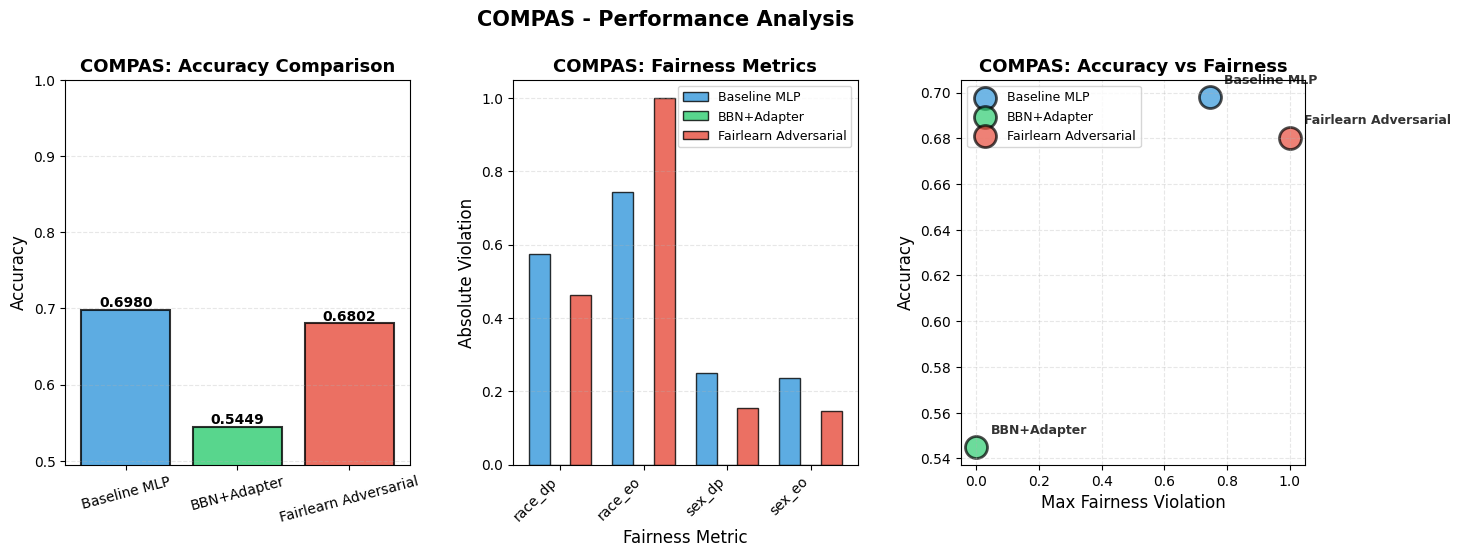

✓ COMPAS completed successfully


▶ PROCESSING GERMAN DATASET
Cached German data to /kaggle/working/preproc_german.pkl

Using best parameters for german:
  lambda_adv: 0.15
  alpha_bbn: 1.0
  lr: 0.0015
  hidden_dim: 128


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'status': 'N', 'duration': 'N', 'credit_history': 'N', 'purpose': 'N', 'amount': 'N', 'savings': 'N', 'employment': 'N', 'installment_rate': 'N', 'other_debtors': 'N', 'residence': 'N', 'property': 'N', 'other_installment_plans': 'N', 'housing': 'N', 'number_credits': 'N', 'job': 'N', 'people_liable': 'N', 'telephone': 'N', 'sex_label': 'N', 'age_label': 'N', 'foreign_worker_label': 'N', 'credit_label': 'N'}



Training Fairlearn AdversarialFairnessClassifier for german...
Accuracy: 0.3300

Generating visualizations...


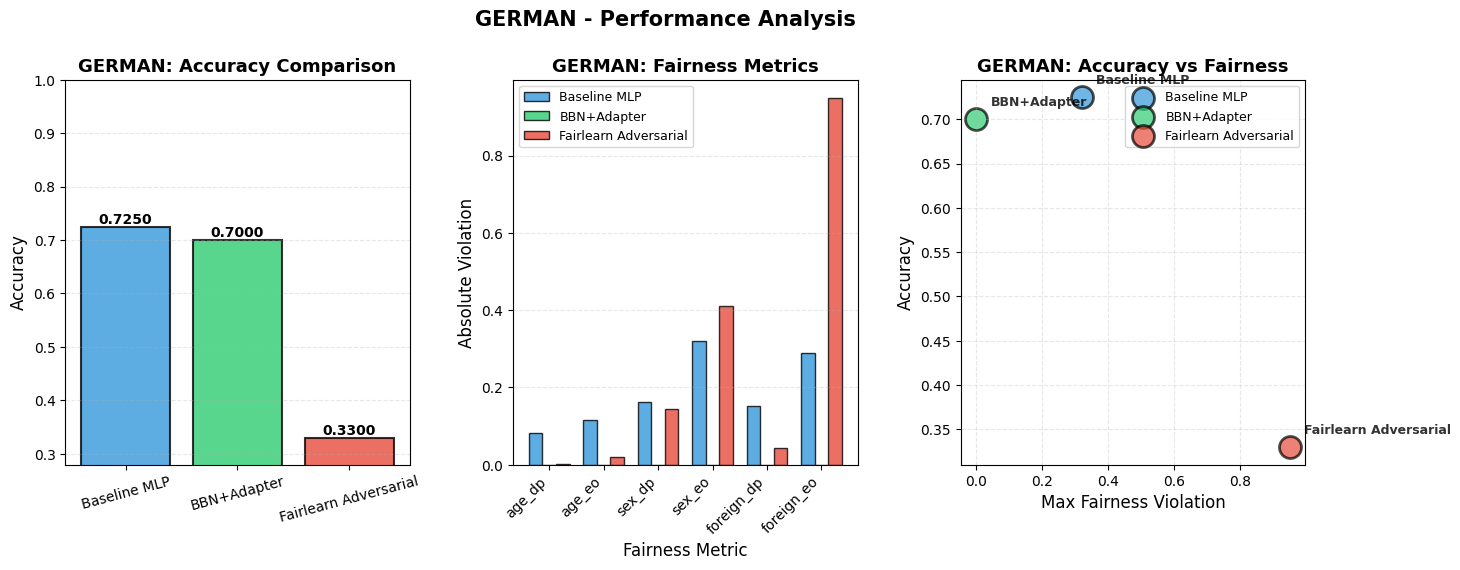

✓ GERMAN CREDIT completed successfully


▶ PROCESSING BANK DATASET
Cached Bank data to /kaggle/working/preproc_bank.pkl

Using best parameters for bank:
  lambda_adv: 0.15
  alpha_bbn: 1.0
  lr: 0.0015
  hidden_dim: 128


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'balance': 'N', 'day': 'N', 'duration': 'N', 'campaign': 'N', 'pdays': 'N', 'previous': 'N', 'marital': 'N', 'job': 'N', 'y': 'N'}



Training Fairlearn AdversarialFairnessClassifier for bank...
Accuracy: 0.7769

Generating visualizations...


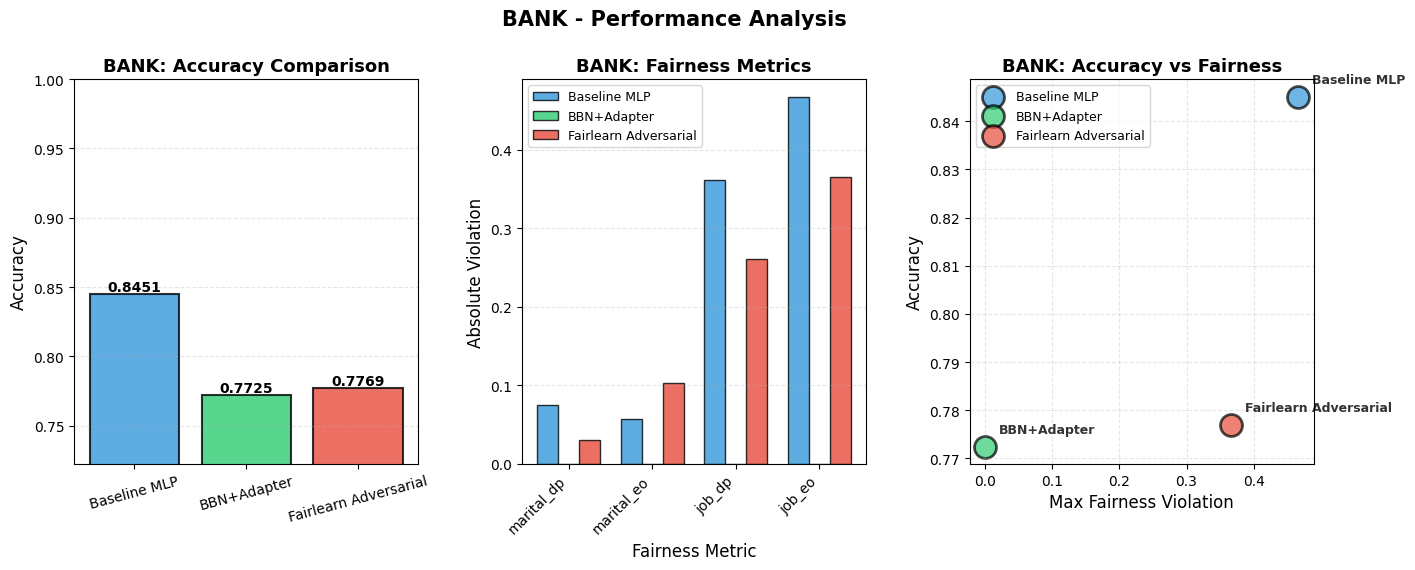

✓ BANK completed successfully


▶ PROCESSING LAWSCHOOL DATASET
Cached Law School data to /kaggle/working/preproc_lawschool.pkl

Using best parameters for lawschool:
  lambda_adv: 0.5
  alpha_bbn: 5.0
  lr: 0.0001
  hidden_dim: 64


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lsat': 'N', 'ugpa': 'N', 'fulltime': 'N', 'fam_inc': 'N', 'age': 'N', 'race': 'N', 'gender': 'C', 'income': 'N'}
INFO:fairlearn.adversarial._adversarial_mitigation:|=========>           | Epoch: 1/1, Batch: 32/70, ETA: 0.13 sec. Loss (pred/adv): 0.40/1.94



Training Fairlearn AdversarialFairnessClassifier for lawschool...


INFO:fairlearn.adversarial._adversarial_mitigation:|=================>   | Epoch: 1/1, Batch: 62/70, ETA: 0.03 sec. Loss (pred/adv): 0.36/1.85


Accuracy: 0.9075

Generating visualizations...


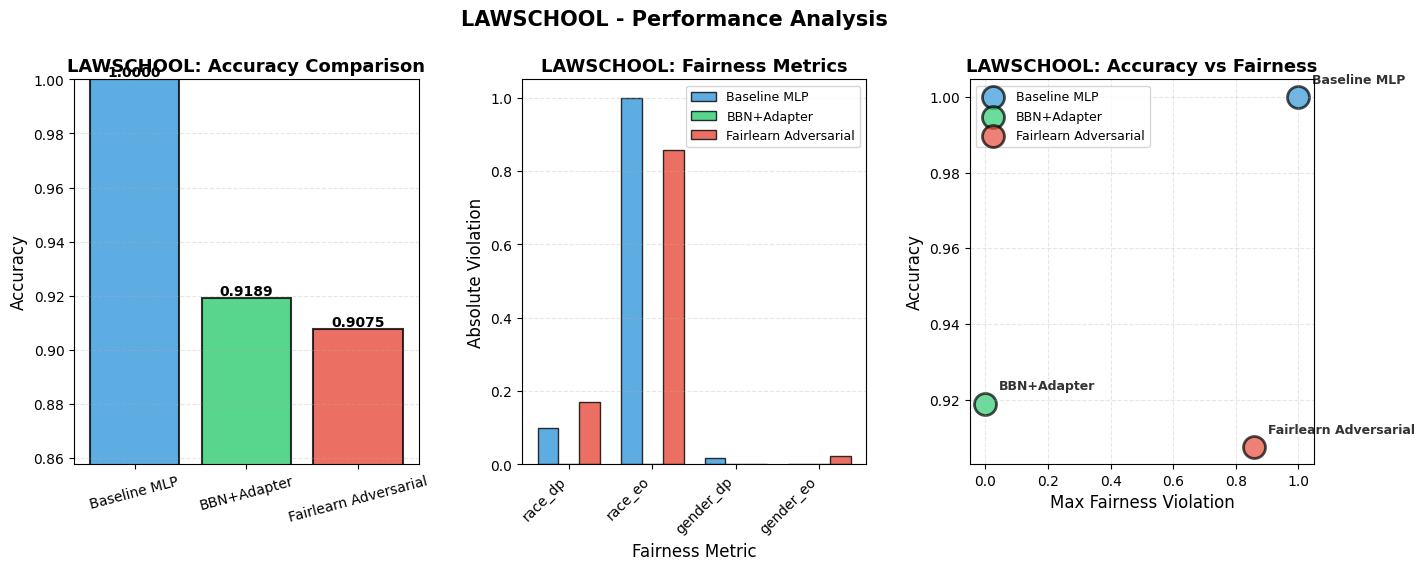

✓ LAWSCHOOL completed successfully


▶ PROCESSING HOSPITAL DATASET
Cached Hospital data to /kaggle/working/preproc_hospital.pkl

Using best parameters for hospital:
  lambda_adv: 0.1
  alpha_bbn: 0.3
  lr: 0.001
  hidden_dim: 96


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'race': 'N', 'gender': 'N', 'age': 'N', 'discharge_disposition_id': 'N', 'admission_source_id': 'N', 'time_in_hospital': 'N', 'medical_specialty': 'N', 'num_lab_procedures': 'N', 'num_procedures': 'N', 'num_medications': 'N', 'primary_diagnosis': 'N', 'number_diagnoses': 'N', 'insulin': 'N', 'change': 'N', 'diabetesMed': 'N', 'medicare': 'N', 'medicaid': 'N', 'had_emergency': 'N', 'had_inpatient_days': 'N', 'had_outpatient_days': 'N', 'readmitted': 'C', 'readmit_binary': 'N', 'race_label': 'N', 'gender_label': 'N'}
INFO:fairlearn.adversarial._adversarial_mitigation:|====>                | Epoch: 1/1, Batch: 32/162, ETA: 0.43 sec. Loss (pred/adv): 0.66/1.73



Training Fairlearn AdversarialFairnessClassifier for hospital...


INFO:fairlearn.adversarial._adversarial_mitigation:|========>            | Epoch: 1/1, Batch: 62/162, ETA: 0.33 sec. Loss (pred/adv): 0.66/1.68
INFO:fairlearn.adversarial._adversarial_mitigation:|===========>         | Epoch: 1/1, Batch: 92/162, ETA: 0.24 sec. Loss (pred/adv): 0.68/1.61
INFO:fairlearn.adversarial._adversarial_mitigation:|===============>     | Epoch: 1/1, Batch: 123/162, ETA: 0.13 sec. Loss (pred/adv): 0.66/1.54
INFO:fairlearn.adversarial._adversarial_mitigation:|===================> | Epoch: 1/1, Batch: 153/162, ETA: 0.03 sec. Loss (pred/adv): 1.17/1.50


Accuracy: 0.5580

Generating visualizations...


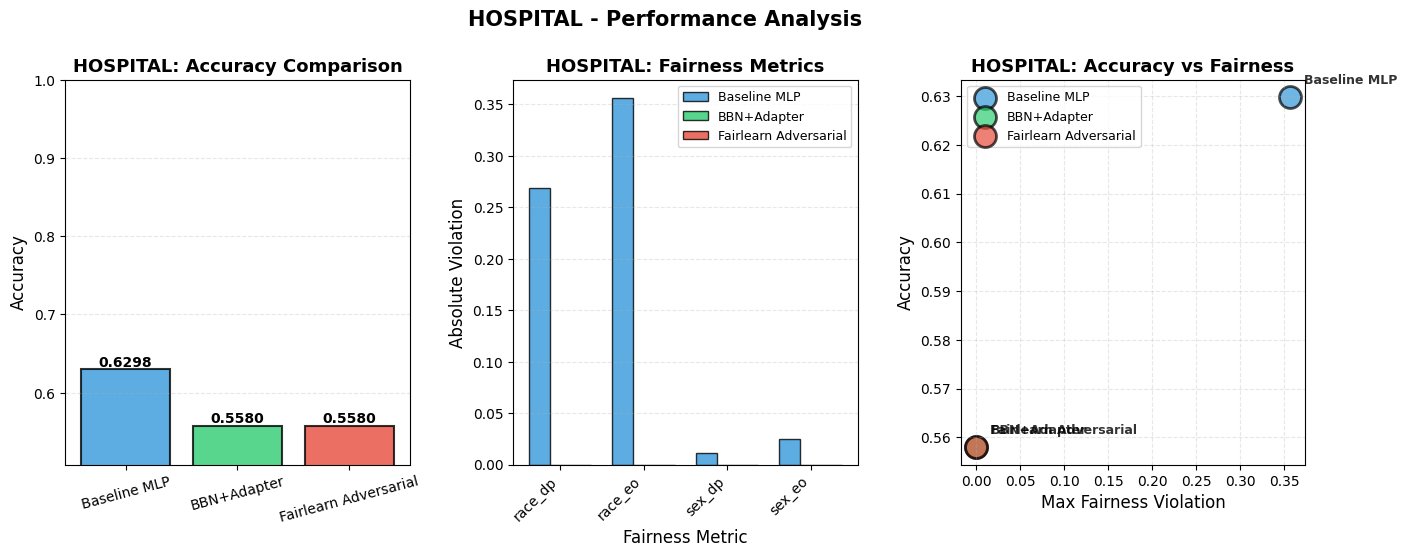

✓ DIABETES HOSPITAL completed successfully


FINAL SUMMARY - ALL DATASETS

COMPAS:
  Baseline Accuracy: 0.6980
  BBN+Adapter Accuracy: 0.5449
  Fairlearn Adversarial Accuracy: 0.6802

  Accuracy Comparison:
    BBN+Adapter Drop: 0.1530
    Fairlearn Drop: 0.0178

  Fairness Comparison (Max Violation):
    Baseline: 0.7448
    BBN+Adapter: 0.0000
    Fairlearn Adversarial: 1.0000

  Fairness Improvement vs Baseline:
    BBN+Adapter: 0.7448
    Fairlearn Adversarial: -0.2552

  Detailed Metrics by Method:
  Baseline:
    race_dp: 0.5741
    race_eo: 0.7448
    sex_dp: 0.2509
    sex_eo: 0.2377
  BBN+Adapter:
    race_dp: 0.0000
    race_eo: 0.0000
    sex_dp: 0.0000
    sex_eo: 0.0000
  Fairlearn Adversarial:
    race_dp: 0.4633
    race_eo: 1.0000
    sex_dp: 0.1543
    sex_eo: 0.1464

GERMAN:
  Baseline Accuracy: 0.7250
  BBN+Adapter Accuracy: 0.7000
  Fairlearn Adversarial Accuracy: 0.3300

  Accuracy Comparison:
    BBN+Adapter Drop: 0.0250
    Fairlearn Drop: 0.3950

  Fairness Comp

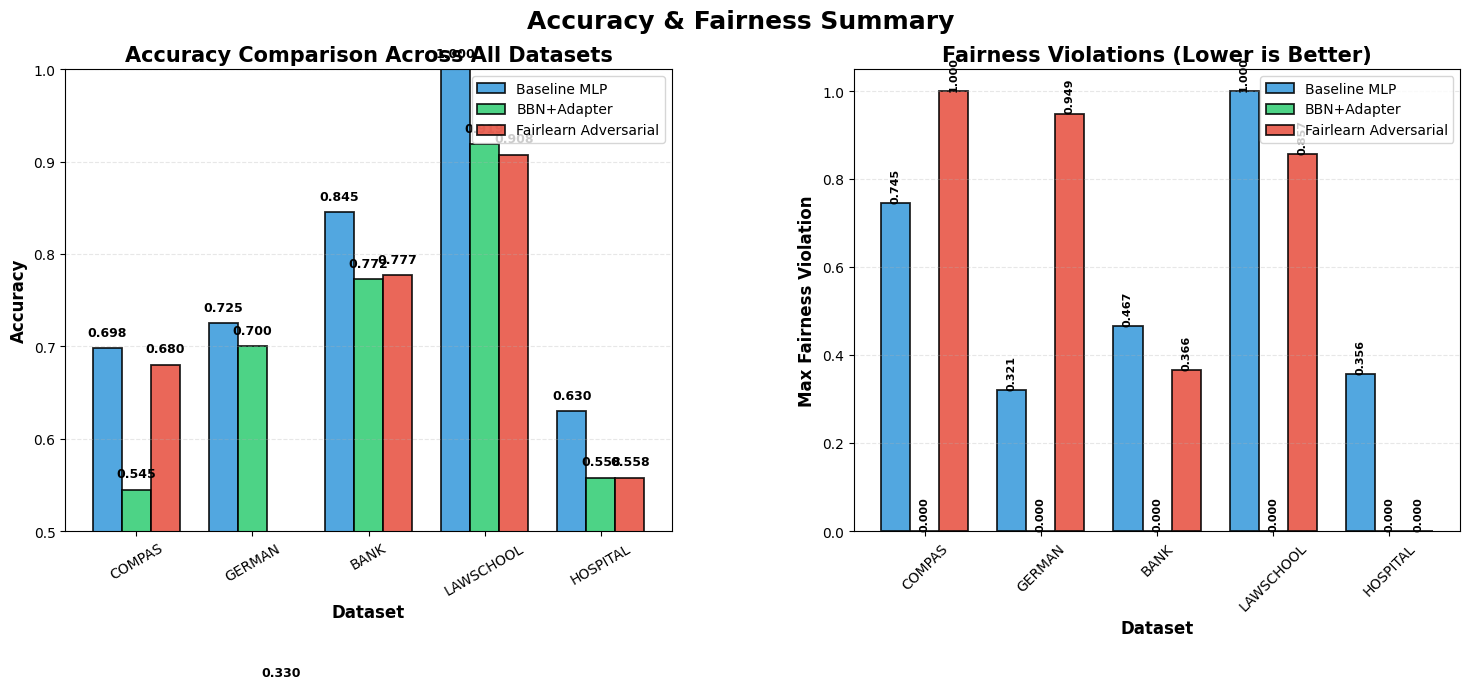

In [10]:
if __name__ == '__main__':
    print("=" * 70)
    print("FAIR BBN SYSTEM WITH FAIRLEARN ADVERSARIAL COMPARISON")
    print("=" * 70)
    print(f"Device: {device}")
    print("=" * 70)
    
    datasets = [
        ("COMPAS", preprocess_compas_for_fair_bbn, "compas"),
        ("GERMAN CREDIT", preprocess_german_for_fair_bbn, "german"),
        ("BANK", preprocess_bank_for_fair_bbn, "bank"),
        ("LAWSCHOOL", preprocess_lawschool_for_fair_bbn, "lawschool"),
        ("DIABETES HOSPITAL", preprocess_diabetes_hospital_for_fair_bbn, "hospital"),
    ]
    
    all_results = {}
    all_best_params = {}
    
    for name, preprocess_func, dataset_name in datasets:
        print(f"\n{'=' * 70}\n▶ PROCESSING {dataset_name.upper()} DATASET\n{'=' * 70}")
        
        try:
            data = preprocess_func(use_cache=True)
            
            results, best_params = run_with_best_params(data, dataset_name, verbose=True)
            fairlearn_results = run_fairlearn_adversarial(data, dataset_name, verbose=True)
            
            all_results[dataset_name] = {
                'baseline': results['baseline'],
                'bbn_adapter': results['bbn_adapter'],
                'fairlearn_adversarial': fairlearn_results
            }
            all_best_params[dataset_name] = best_params
            
            print("\nGenerating visualizations...")
            plot_dataset_comparison(all_results[dataset_name], dataset_name)
            print(f"✓ {name} completed successfully\n")
            
        except Exception as e:
            print(f"✗ {name} failed: {str(e)}\n")
            import traceback
            traceback.print_exc()
            continue
    
    print_final_summary(all_results)
    
    print("\nGenerating accuracy & fairness summary...")
    plot_accuracy_and_fairness_only(all_results)

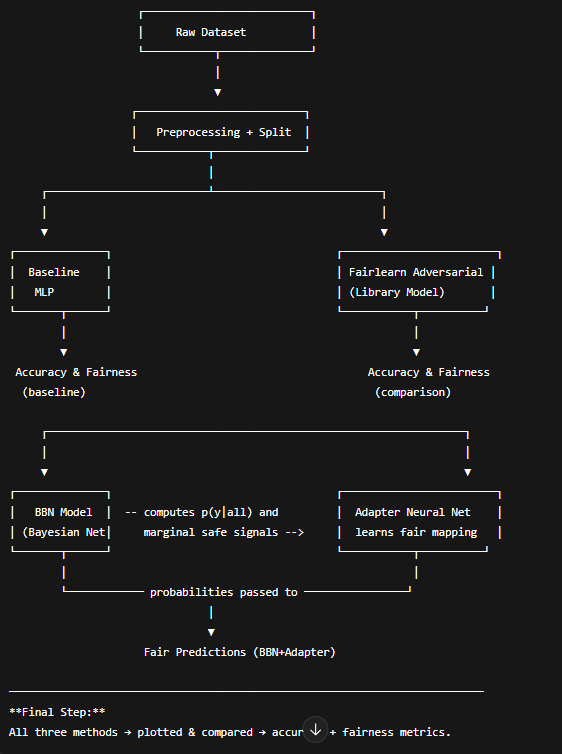